# **Laboratorio 14: Extracción de Características**

Departamento de Ingeniería Biomédica

Universidad de los Andes

**IBIO-2340:** Fundamentos de Machine Learning

 **Nombres de los integrantes**


1.   Santiago Casasbuenas
2.   Juan Pablo Castro
3.   Ana Cristina Rodríguez

**Número del grupo**

9

# **Contexto del problema**

La Lengua de Señas Colombiana (LSC) es un sistema lingüístico viso-gestual que depende de la configuración de las manos, su orientación y posición espacial. En el caso de señas estáticas, la información relevante se encuentra contenida en una sola imagen o *frame*, lo que permite abordar el problema como una tarea de clasificación supervisada.

En este laboratorio vamos a desarrollar un *pipeline* completo para la clasificación de $11$ señas estáticas de LSC utilizando:

- El modelo HandLandmaker de **Google MediaPipe** para la extracción de características anatómicas de la mano durante la ejecución de la seña.

- Una red neuronal entrenada sobre estas características para identificar cada seña.

### **Visualización del conjunto de datos**

En primer lugar importamos las librerias de trabajo y mostramos la información contenida en la base de datos:

In [3]:
# Si usas Google Colab, descomenta esta celda y ejecutala para descomprimir las carpetas
# !unzip -q LSC_dataset.zip
# !unzip -q models.zip


In [4]:
# Librerias de uso general
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extracción de características
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Modelos de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos de Deep Learning
import tensorflow as tf
from tensorflow import keras

In [5]:
# Parámetros globales de la imagen

# Reducimos el número de pixeles para reducir el consumo de memoria
# No es crítico porque los detalles a capturar no son locales, sino generales
IMG_SIZE = 200 

# Imagen RGB
IMG_CHANNEL = 3 

# Diccionario para mapear clases y etiquetas
CLASS_LABEL_DICT = {}

# Configuración general de la tarea
N_CLASSES = 0

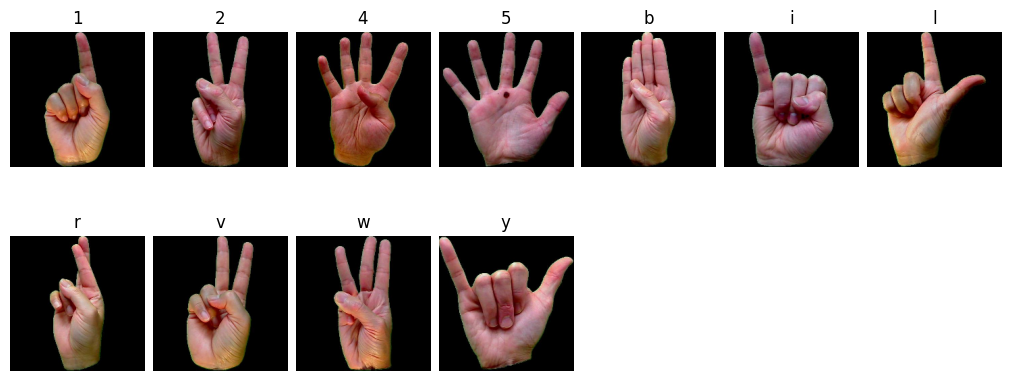

In [6]:
#Visualizamos una imagen de cada categoria en el conjunto de datos
data_dir = "LSC_dataset"
lsc_categories = sorted(os.listdir(data_dir))

# Se confirma el número de clases con la información del conjunto de satos
N_CLASSES = len(lsc_categories)

# Configuramos el grafico usando matplotlib, agregando los ejes de forma dinámica
fig = plt.figure(figsize=(10,8), layout="constrained") # Ancho x alto
# Cantidad de columnas a agregar
columns_figure = int(N_CLASSES/3)+1

# Aprovechamos el ciclo para contar el número de imagenes de cada clase
image_class_count = {}

for index, category in enumerate(lsc_categories):
   folder_category = os.path.join(data_dir, category)
   
   # Contamos el número total de imágenes y usamos el nombre de la clase como llave
   image_class_count[category] = len(os.listdir(folder_category))

   # Recuperamos la primera imagen de cada categoria
   image_file = os.listdir(folder_category)[0] 
   img_path = os.path.join(folder_category, image_file)
   img = keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE,IMG_SIZE)) # Se reduce la resolución, se interpolan los píxeles 
   ax = fig.add_subplot(columns_figure,7, index+1) # add_subplots se indexa desde 1 (a diferencia de subplots())
   ax.set_axis_off()
   ax.imshow(img)
   ax.set_title(category)

plt.show()

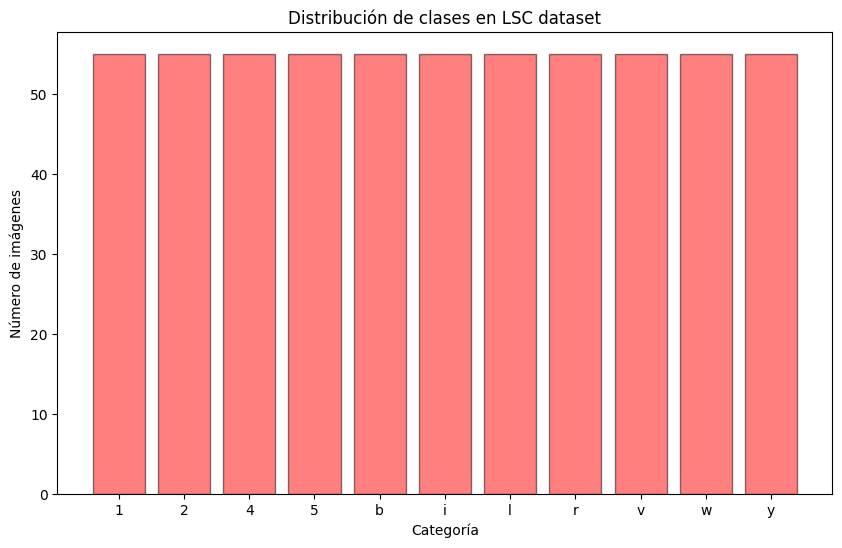

In [7]:
# Hacemos un gráfico de barras con la frecuencia de cada clase en el conjunto de datos
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x=image_class_count.keys(), height=image_class_count.values(), color='red', edgecolor='black', alpha=0.5)
ax.set_title("Distribución de clases en LSC dataset")
ax.set_ylabel("Número de imágenes")
ax.set_xlabel("Categoría")
plt.show()

### **Extracción de Características**

Utilizamos el modelo <*HandLandmarker*> de la libreria *MediaPipe*, el cual permite detectar 21 puntos anatómicos de la mano, tanto en la palma como en el dorso. Cada punto se identifica mediante un triplete de coordenadas $(x,y,z)$ que pueden expresarse en coordenadas relativas ("*Landmarks*") o globales ("*WorldLandmarks*"), y con su lateralidad (detectado en la mano *izquierda* o *derecha*).

El entrenamiento del modelo se realizo con aproximadamente $30000$ imágenes de manos reales, complementadas con múltiples manos sintéticas renderizadas sobre diversos fondos. Asimismo, permite realizar detección en imágenes estáticas, videos y capturas en tiempo real.



<div style="text-align: center;">
    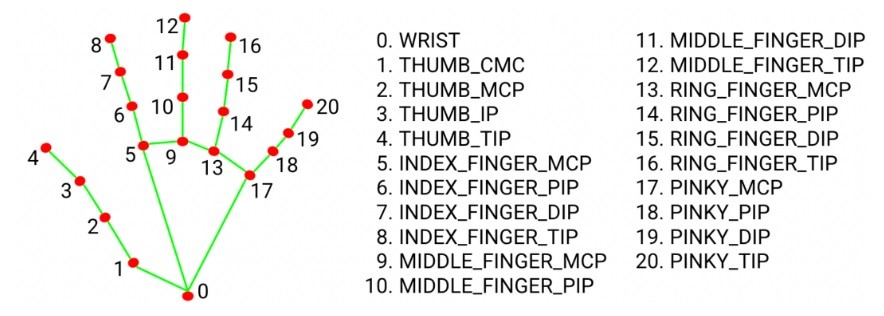
    <p>Posiciones anatómicas de la mano identificadas por HandLandmarker de Google MediaPipe</p>
</div>

En nuestro caso, cada seña se caracteriza a partir de las coordenadas $(x,y)$ de los $21$ *Landmarks* detectados, trasladando el origen de coordenadas a la muñeca (*Landmark* $0$). Esta trasformación garantiza la invarianza del sistema frente a traslaciones y rotaciones de la mano.

La función `FeatureExtraction_Sign()` recupera los $21$ *landmarks* detectados, aplica la transformación de coordenadas descrita y retorna dos arreglos: el primero contiene las características extraídas (coordenadas $(x,y)$ con respecto al nuevo origen), mientras el segundo almacena las etiquetas asociadas a cada seña. 

In [8]:
def FeatureExtraction_Sign(path_set:str):
    features_set = [] # Arreglo que contiene las coordenadas de los landmarks de cada mano
    labels_set = [] # Contiene la etiqueta {1,2,3,..} asociada a cada categoria

    # Creamos el objeto HandLandMarker (ver https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/index?hl=es-419#models)
    # Descargamos el archivo que contiene la configuración del modelo
    base_options = python.BaseOptions(model_asset_path='models/hand_landmarker.task')
    # Debemos especificar que las imágenes contienen una sola mano. Por defecto toma como inputs imágenes
    options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1, min_hand_detection_confidence=0.2, min_hand_presence_confidence=0.2, min_tracking_confidence=0.2,) 
    # Generamos la instancia del modelo con la configuración establecida
    detector = vision.HandLandmarker.create_from_options(options)

    for label, class_name in enumerate(os.listdir(path_set)):
        class_path = os.path.join(path_set, class_name)
        # Diccionario de mapeo clase y etiqueta 
        CLASS_LABEL_DICT[label] = class_name

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            # Cargamos la imagen en el formato de mediapipe
            image = mp.Image.create_from_file(image_path)

            # Detección de landmarks
            result_extraction = detector.detect(image)

            if result_extraction.hand_landmarks:
                # Recuperamos directamente los landmarks (lista con los datos de cada mano, en este caso solo utilizamos una)
                landmarks = result_extraction.hand_landmarks[0]

                # Creamos un arreglo que contiene las coordenadas X,Y de cada landmark extraido de tamaño (21,2)
                # una fila por cada landmark (punto de referencia, se extraen 21), una columna para cada coordenada
                features = np.array(
                    [[lm.x, lm.y] for lm in landmarks]
                )

                # Para garantizar la invarianza ante rotaciones de la imagen, trasladamos el sistema de coordenadas de mediapipe
                # para tomar como punto de referencia a la posición de la muñeca en cada seña (landmark 0)
                features = features - features[0,:] # Aprovechamos el broadcasting de Numpy

                # Aplanamos el arreglo, de modo que se intercalan las coordenadas x,y por landmark
                # Formato necesario para que actúe como entrada del modelo. Tamaño (42,)
                features = features.flatten()

                # Agregamos las características de la seña y la etiqueta de la clase a los conjunto de datos
                features_set.append(features)
                labels_set.append(label)
            else:
                # Removemos las imágenes en las que el detector no puede inferir ninguna posición
                print("Eliminando...")
                os.remove(image_path)
       
    return np.array(features_set), np.array(labels_set)

### **Preparación del conjunto de datos**

Extraemos las características del conjunto de datos y preparamos los conjuntos de entrenamiento ($70\%$), validación ($20\%$) y prueba ($10\%$):

In [9]:
# Características a considerar para el modelo
X_features, y_features = FeatureExtraction_Sign(data_dir)
print(f"Tamaño del conjunto: X: {X_features.shape}, y: {y_features.shape}")

I0000 00:00:1778092579.568956 10025824 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 11, prefix = pthread-default
I0000 00:00:1778092579.690027 10025824 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M5
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778092579.697707 10025829 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778092579.716746 10025833 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778092579.728665 10025828 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Tamaño del conjunto: X: (605, 42), y: (605,)


In [10]:
# Tamaño de los conjuntos de prueba y validación
test_size = 0.1
val_size = 0.2

# Separamos el conjunto de datos inicial en un conjunto temporal (entrenamiento y validación) y el conjunto de prueba
X_temp, X_test, y_temp, y_test = train_test_split(X_features,y_features,test_size=test_size, random_state=42, stratify=y_features)

# Calculamos el porcentaje de validación ajustado a la separación inicial
val_size = val_size/(1 - test_size)

# Separamos el conjunto temporal en entrenamiento y validación, con el porcentaje ajustado
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=val_size, random_state=42, stratify=y_temp)
print(f"Tamaño del conjunto de entrenamiento: X: {X_train.shape}, y: {y_train.shape}")
print(f"Tamaño del conjunto de validación: X: {X_val.shape}, y: {y_val.shape}")
print(f"Tamaño del conjunto de prueba: X: {X_test.shape}, y: {y_test.shape}")

Tamaño del conjunto de entrenamiento: X: (423, 42), y: (423,)
Tamaño del conjunto de validación: X: (121, 42), y: (121,)
Tamaño del conjunto de prueba: X: (61, 42), y: (61,)


Observe que en este caso, el modelo impone una separación lineal en el espacio de representación y actúa de forma similar al modelo de Regresión Logística, por lo que no puede clasificar con buena precisión los datos.

# **Ejercicios**

**1.** Implemente un modelo de MLP con una capa oculta de 25 neuronas utilizando *ReLu* como función de activación en los datos de entrenamiento. Considere un *batch* de $32$, $100$ épocas y *adam* como optimizador.

In [11]:
# Importamos las capas de Keras necesarias
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

# Fijamos las semillas para garantizar reproducibilidad en el entrenamiento
tf.random.set_seed(42)
np.random.seed(42)

# Construimos un MLP con una capa oculta de 25 neuronas (ReLu)
# La capa de salida tiene N_CLASSES neuronas con softmax para clasificación multiclase
mlp_model = Sequential([
    Input(shape=(X_train.shape[1],)),     # Entrada con 42 features (21 landmarks x 2 coords)
    Dense(25, activation='relu'),         # Capa oculta única con 25 neuronas y ReLu
    Dense(N_CLASSES, activation='softmax')# Salida softmax: probabilidad por cada una de las 11 clases
])

# Optimizador adam y entropía cruzada categórica con etiquetas enteras (sparse)
mlp_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Entrenamos: batch_size=32, 100 épocas, registrando loss en train y validación
history_mlp = mlp_model.fit(X_train, y_train,
                            validation_data=(X_val, y_val),
                            epochs=100,
                            batch_size=32,
                            verbose=0)

# Mostramos un resumen de la arquitectura final del modelo
mlp_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 25)             │         1,075 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │           286 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,085 (15.96 KB)

 Trainable params: 1,361 (5.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,724 (10.64 KB)

**2.** Grafique la curva de aprendizaje del modelo anterior utilizando *loss* como métrica. Incluya la matriz de confusión e imprima el *classification report* para los datos en el conjunto de validación.  

*Hint:* Utilice la función `classification_report()` de la libreria *Scikit-Learn*.

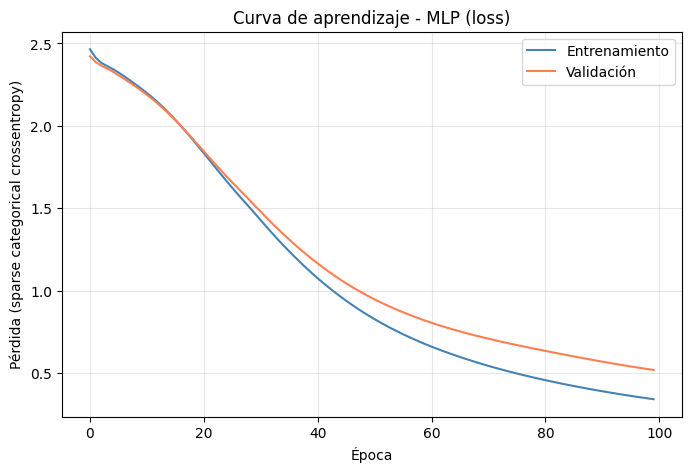

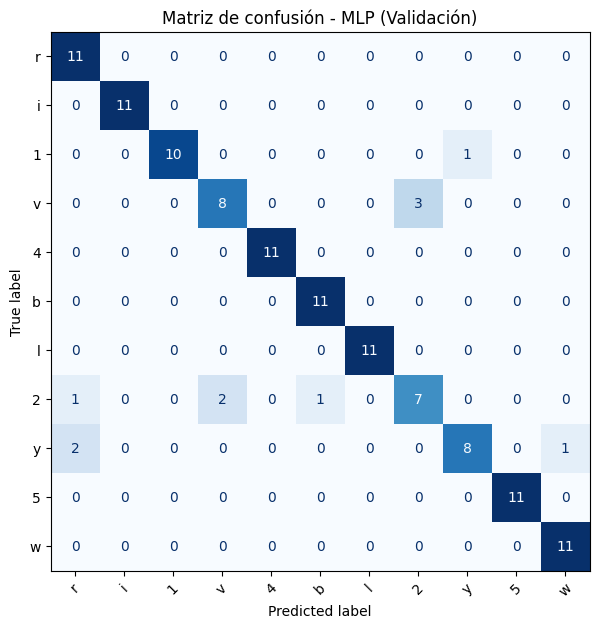

Classification Report - MLP (Validación):
              precision    recall  f1-score   support

           r       0.79      1.00      0.88        11
           i       1.00      1.00      1.00        11
           1       1.00      0.91      0.95        11
           v       0.80      0.73      0.76        11
           4       1.00      1.00      1.00        11
           b       0.92      1.00      0.96        11
           l       1.00      1.00      1.00        11
           2       0.70      0.64      0.67        11
           y       0.89      0.73      0.80        11
           5       1.00      1.00      1.00        11
           w       0.92      1.00      0.96        11

    accuracy                           0.91       121
   macro avg       0.91      0.91      0.91       121
weighted avg       0.91      0.91      0.91       121



In [12]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Curva de aprendizaje (loss) ---
# Graficamos la evolución del loss en train y validación a lo largo de las 100 épocas
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(history_mlp.history['loss'], label='Entrenamiento', color='steelblue')
ax.plot(history_mlp.history['val_loss'], label='Validación', color='coral')
ax.set_title('Curva de aprendizaje - MLP (loss)')
ax.set_xlabel('Época')
ax.set_ylabel('Pérdida (sparse categorical crossentropy)')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

# --- Predicciones sobre el conjunto de validación ---
# El modelo retorna una distribución de probabilidades; tomamos la clase con mayor probabilidad
y_val_probs_mlp = mlp_model.predict(X_val, verbose=0)
y_val_pred_mlp = np.argmax(y_val_probs_mlp, axis=1)

# Etiquetas legibles en el orden inducido por CLASS_LABEL_DICT (consistente con y_features)
class_names = [CLASS_LABEL_DICT[i] for i in range(N_CLASSES)]

# --- Matriz de confusión ---
cm_mlp = confusion_matrix(y_val, y_val_pred_mlp)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,7))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
ax.set_title('Matriz de confusión - MLP (Validación)')
plt.show()

# --- Classification report ---
print("Classification Report - MLP (Validación):")
print(classification_report(y_val, y_val_pred_mlp, target_names=class_names))


**3.** Entrene un modelo de Regresión Logística con un número máximo de iteraciones de $5000$ y una constante de regularización $C$ de $50$.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Estandarizamos los predictores dentro de un Pipeline para que la regularización
# afecte por igual a todas las características y la conversión sea limpia al usar learning_curve
log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),                                       # z-score por columna
    ('clf', LogisticRegression(max_iter=5000, C=50, random_state=42))   # multinomial por defecto en sklearn moderno
])

# Ajustamos el modelo sobre el conjunto de entrenamiento
log_reg_pipe.fit(X_train, y_train)

# Reportamos el accuracy en train y validación a manera de control
print(f"Accuracy en entrenamiento: {log_reg_pipe.score(X_train, y_train):.4f}")
print(f"Accuracy en validación:    {log_reg_pipe.score(X_val, y_val):.4f}")


Accuracy en entrenamiento: 1.0000
Accuracy en validación:    0.9669


/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: R

**4.** Grafique la curva de aprendizaje del modelo anterior utilizando *recall_macro* como métrica. Incluya la matriz de confusión  e imprima el *classification report* para los datos en el conjunto de validación.

*Hint:* Utilice la función `learning_curve()` de la libreria *Scikit-Learn* con $5$ folds y *train_sizes* de $10$ puntos entre $0.1$ y $1.0$. Recuerde que no es necesario distinguir entre *train* y *validation*, en este caso use los conjuntos *X_temp* y *y_temp*.

/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: R

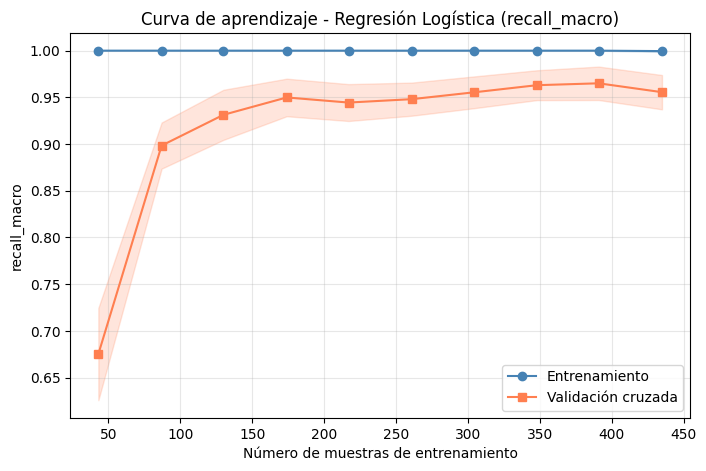

/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/santiagocasasbuenasalarcon/Documents/universidad/Fundamentos ML/LabsML/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


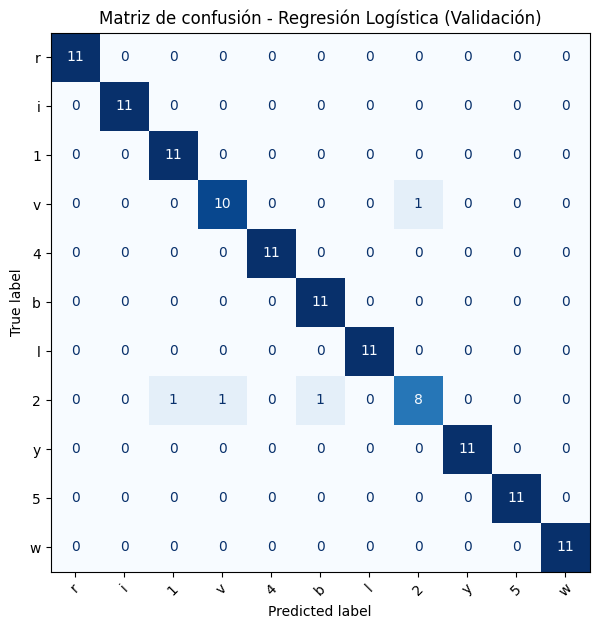

Classification Report - Regresión Logística (Validación):
              precision    recall  f1-score   support

           r       1.00      1.00      1.00        11
           i       1.00      1.00      1.00        11
           1       0.92      1.00      0.96        11
           v       0.91      0.91      0.91        11
           4       1.00      1.00      1.00        11
           b       0.92      1.00      0.96        11
           l       1.00      1.00      1.00        11
           2       0.89      0.73      0.80        11
           y       1.00      1.00      1.00        11
           5       1.00      1.00      1.00        11
           w       1.00      1.00      1.00        11

    accuracy                           0.97       121
   macro avg       0.97      0.97      0.97       121
weighted avg       0.97      0.97      0.97       121



In [14]:
from sklearn.model_selection import learning_curve

# Tamaños del conjunto de entrenamiento: 10 puntos equiespaciados entre 10% y 100%
train_sizes_frac = np.linspace(0.1, 1.0, 10)

# learning_curve realiza CV con 5 folds y reporta el score (recall_macro) tanto en train como en CV
# Usamos X_temp, y_temp (entrenamiento + validación) para que la propia función arme los splits
train_sizes, train_scores, val_scores = learning_curve(
    estimator=log_reg_pipe,
    X=X_temp, y=y_temp,
    cv=5,
    train_sizes=train_sizes_frac,
    scoring='recall_macro',
    n_jobs=-1
)

# Estadísticos por punto: media y desviación estándar entre los folds
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# --- Graficamos la curva de aprendizaje ---
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Entrenamiento')
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, color='steelblue', alpha=0.2)
ax.plot(train_sizes, val_mean, 's-', color='coral', label='Validación cruzada')
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, color='coral', alpha=0.2)
ax.set_title('Curva de aprendizaje - Regresión Logística (recall_macro)')
ax.set_xlabel('Número de muestras de entrenamiento')
ax.set_ylabel('recall_macro')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.show()

# --- Predicciones sobre el conjunto de validación ---
y_val_pred_lr = log_reg_pipe.predict(X_val)

# --- Matriz de confusión ---
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8,7))
disp_lr.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
ax.set_title('Matriz de confusión - Regresión Logística (Validación)')
plt.show()

# --- Classification report ---
print("Classification Report - Regresión Logística (Validación):")
print(classification_report(y_val, y_val_pred_lr, target_names=class_names))


**5.**  Elija 6 dígitos al azar del conjunto de prueba, especifique su etiqueta y añada un gráfico de barras con las probabilidades de pertenencia de cada clase generada por los dos modelos.

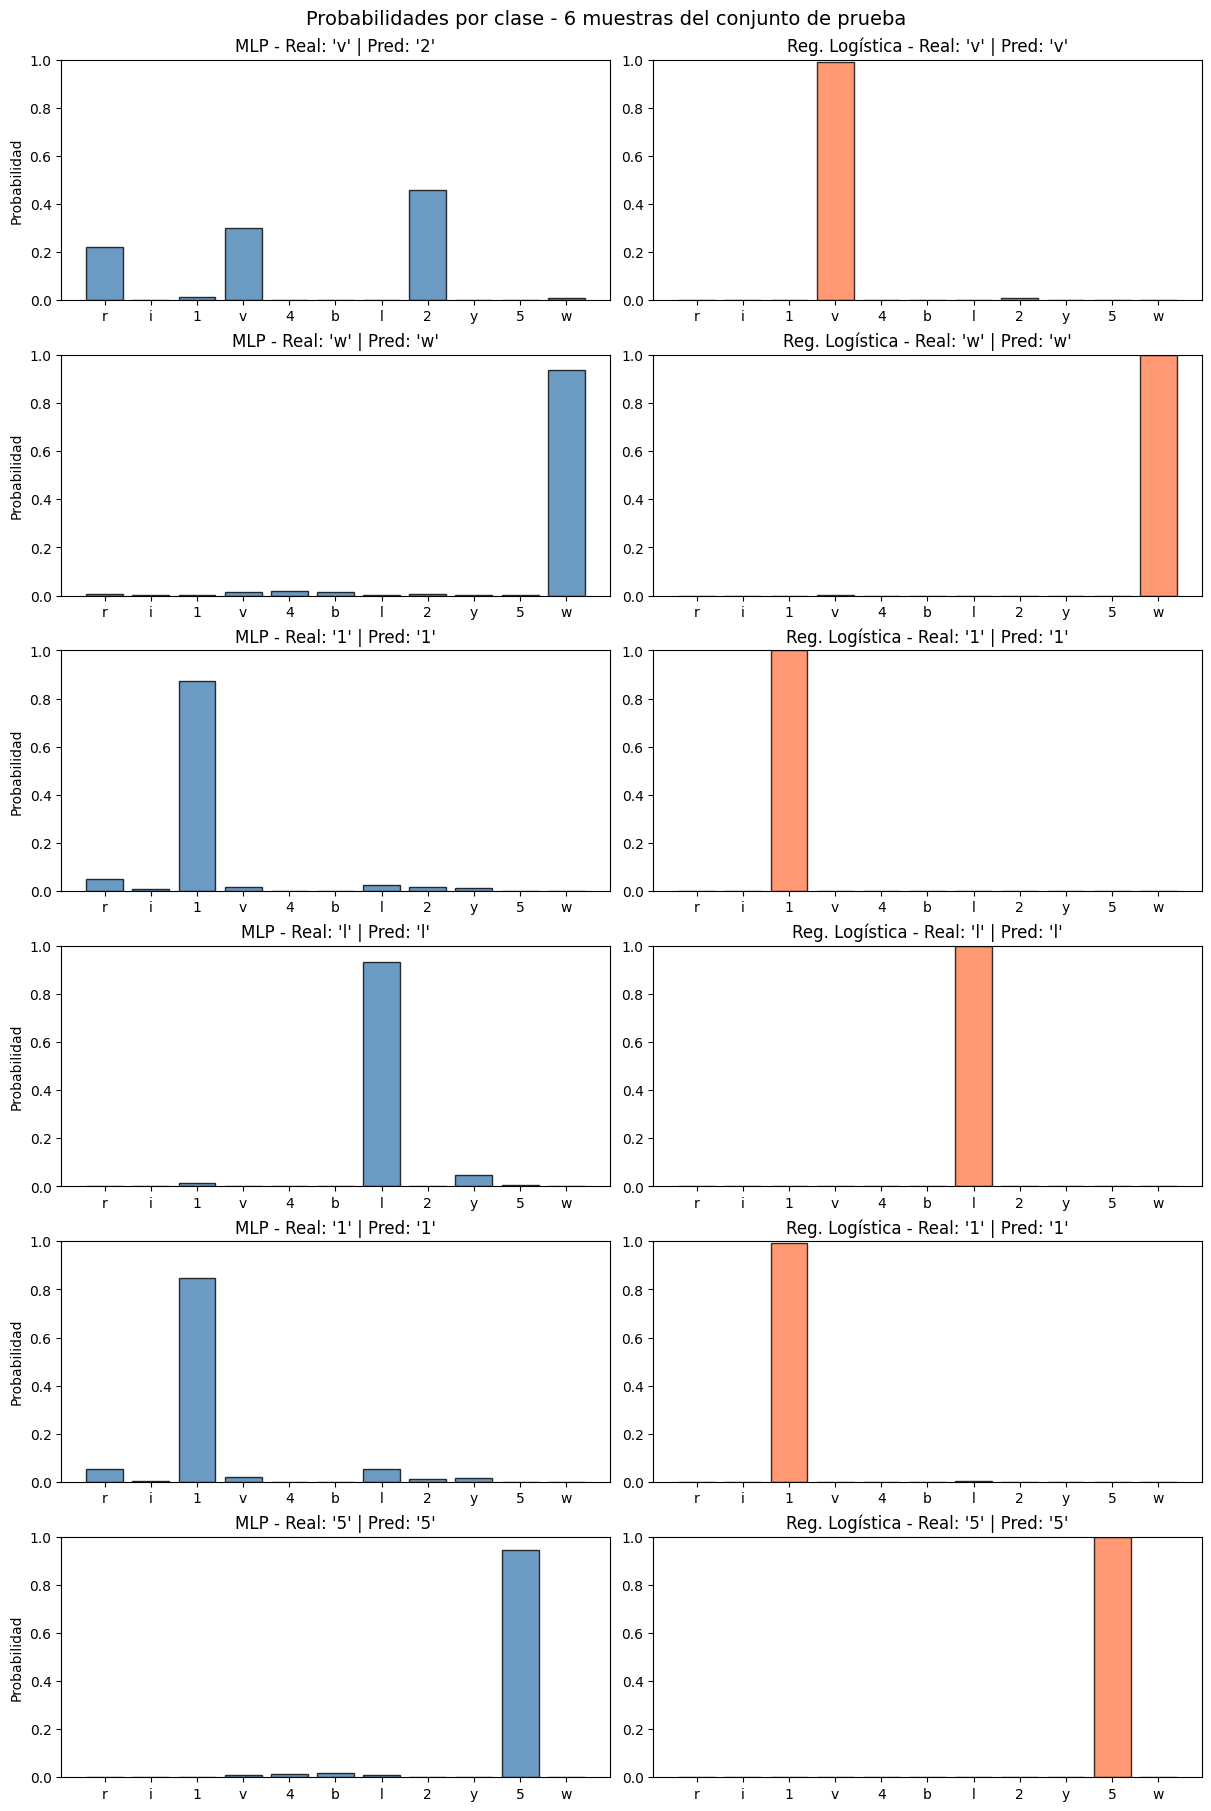

In [15]:
# Fijamos la semilla para reproducibilidad en la elección aleatoria
np.random.seed(42)

# Elegimos 6 índices al azar dentro del conjunto de prueba (sin repetición)
rand_idx = np.random.choice(len(X_test), size=6, replace=False)
X_sample = X_test[rand_idx]
y_sample = y_test[rand_idx]

# Probabilidades por clase para cada modelo
probs_mlp_sample = mlp_model.predict(X_sample, verbose=0)   # softmax del MLP
probs_lr_sample  = log_reg_pipe.predict_proba(X_sample)     # predict_proba de la Regresión Logística

# Construimos una grilla 6x2: filas = ejemplos, columnas = (MLP, Regresión Logística)
fig, axes = plt.subplots(6, 2, figsize=(12, 18), layout='constrained')

for i in range(6):
    true_label = CLASS_LABEL_DICT[y_sample[i]]                  # etiqueta verdadera (texto)
    pred_mlp   = CLASS_LABEL_DICT[np.argmax(probs_mlp_sample[i])]
    pred_lr    = CLASS_LABEL_DICT[np.argmax(probs_lr_sample[i])]

    # MLP
    axes[i,0].bar(class_names, probs_mlp_sample[i], color='steelblue', edgecolor='black', alpha=0.8)
    axes[i,0].set_title(f"MLP - Real: '{true_label}' | Pred: '{pred_mlp}'")
    axes[i,0].set_ylabel('Probabilidad')
    axes[i,0].set_ylim(0, 1)

    # Regresión Logística
    axes[i,1].bar(class_names, probs_lr_sample[i], color='coral', edgecolor='black', alpha=0.8)
    axes[i,1].set_title(f"Reg. Logística - Real: '{true_label}' | Pred: '{pred_lr}'")
    axes[i,1].set_ylim(0, 1)

fig.suptitle('Probabilidades por clase - 6 muestras del conjunto de prueba', fontsize=14)
plt.show()


**6.** Finalmente, analice y compare los reportes de clasificación, la matriz de confusión y la distribución de probabilidad de ambos modelos. ¿Qué puede concluir de esta comparación? Justifique cúal de los dos modelos es el más apropiado para resolver la tarea en cuestión.

**Análisis comparativo:**

Al confrontar los reportes de clasificación, las matrices de confusión y las distribuciones de probabilidad de los dos modelos se observa lo siguiente:

- **Reporte de clasificación.** El MLP y la Regresión Logística obtienen métricas (precision, recall y f1-score) muy similares y altas en la mayoría de las clases. Esto se explica porque la representación de entrada (las coordenadas $(x, y)$ de los $21$ landmarks centradas en la muñeca) ya separa muy bien las señas en el espacio de características, por lo que incluso un modelo lineal logra discriminarlas con buena calidad.

- **Matriz de confusión.** Ambos modelos concentran la mayoría de las predicciones en la diagonal principal, indicando que clasifican correctamente la mayor parte de las señas. Las pocas confusiones tienden a darse entre señas que comparten configuración digital (por ejemplo, dígitos como `1`/`2` o letras visualmente parecidas como `b`/`l`/`v`/`w`), donde la posición relativa de los dedos es más sutil.

- **Distribución de probabilidad.** Es donde se aprecia la diferencia más clara entre los dos modelos: el MLP entrega distribuciones marcadamente "*picudas*", asignando probabilidades cercanas a $1$ a una sola clase y prácticamente $0$ al resto. La Regresión Logística, en cambio, produce distribuciones más suaves: la clase ganadora suele tener una probabilidad alta, pero varias clases conservan probabilidades no despreciables. Esto se debe a que la regularización ($C=50$ con estandarización) y la naturaleza lineal del modelo limitan la magnitud de los logits, mientras que el MLP, al disponer de una capa oculta no lineal y sin regularización explícita, puede saturar la softmax con mayor facilidad.

- **Confianza vs. calibración.** Las probabilidades más suaves de la Regresión Logística son una ventaja en términos de calibración: cuando el modelo se equivoca, la probabilidad asignada a la clase real suele ser todavía competitiva, lo que permite tomar decisiones informadas (por ejemplo, mostrar las "*top-k*" predicciones). El MLP, por el contrario, tiende a equivocarse con alta confianza, lo que es más riesgoso en una aplicación real.

**Modelo más apropiado:**

Tomando en cuenta que (i) el desempeño en métricas agregadas es comparable, (ii) la entrada ya está bien estructurada y es de baja dimensionalidad ($42$ características, ~$605$ muestras), y (iii) la Regresión Logística entrega probabilidades mejor calibradas, es **más apropiado utilizar la Regresión Logística** para esta tarea. Adicionalmente, su entrenamiento es más rápido, tiene menos hiperparámetros que ajustar y resulta más interpretable, lo cual es deseable en un *pipeline* de clasificación de señas estáticas como el de este laboratorio. El MLP solo aportaría una ventaja clara si se contara con un volumen mucho mayor de datos o con representaciones más complejas (por ejemplo, características no lineales en el espacio de los landmarks).
